# Notebook 08 - Analyses complémentaires

Tests et visualisations supplémentaires demandés pour compléter le rapport.

**Prérequis :**
- `runs_cnn_baseline/best_final.pt` (notebook 01)
- `runs_bnn_multimodal/best.pt` (notebook 03)
- `runs_brain_age/best.pt` (notebook 02)
- `predicted_clinical.pkl` (notebook 02)

**Sorties :** `runs_extra/`

### Imports & seed

In [2]:
import os, random, glob, json, time, pickle
import numpy as np
import torch
import torch.nn as nn
import torchbnn as bnn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models, datasets
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.metrics import (mean_absolute_error, r2_score,
                             balanced_accuracy_score, roc_auc_score)
from scipy.stats import gaussian_kde
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import nibabel as nib

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

Device : mps


### Chemins & config

In [3]:
EPIC_ROOT   = "/Users/teodul/Documents/Memoire/Epic and CSCR hospital Dataset"
TRAIN_DIR   = os.path.join(EPIC_ROOT, "Train")
TEST_DIR    = os.path.join(EPIC_ROOT, "Test")
IXI_DIR     = os.path.expanduser("~/Documents/Memoire/IXI")
BR35H_ROOT  = "/Users/teodul/Documents/Memoire/Br35H"
BR35H_YES   = os.path.join(BR35H_ROOT, "yes")
BR35H_NO    = os.path.join(BR35H_ROOT, "no")
BR35H_MASK  = os.path.join(BR35H_ROOT, "Br35H-Mask-RCNN")

CNN_CKPT    = "runs_cnn_baseline/best_final.pt"
BNN_CKPT    = "runs_bnn_multimodal/best.pt"
AGE_CKPT    = "runs_brain_age/best.pt"

SAVE_DIR    = "runs_extra"
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE    = 224
MC_PASSES   = 50
CLASSES     = ["glioma", "meningioma", "notumor", "pituitary"]
AGE_MIN, AGE_MAX = 20, 86

### Transforms & utilitaires

In [5]:
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    return val_tf(img).unsqueeze(0).to(device)

## 1. Présentation des datasets

### 1.1 Epic & CSCR - exemples par classe

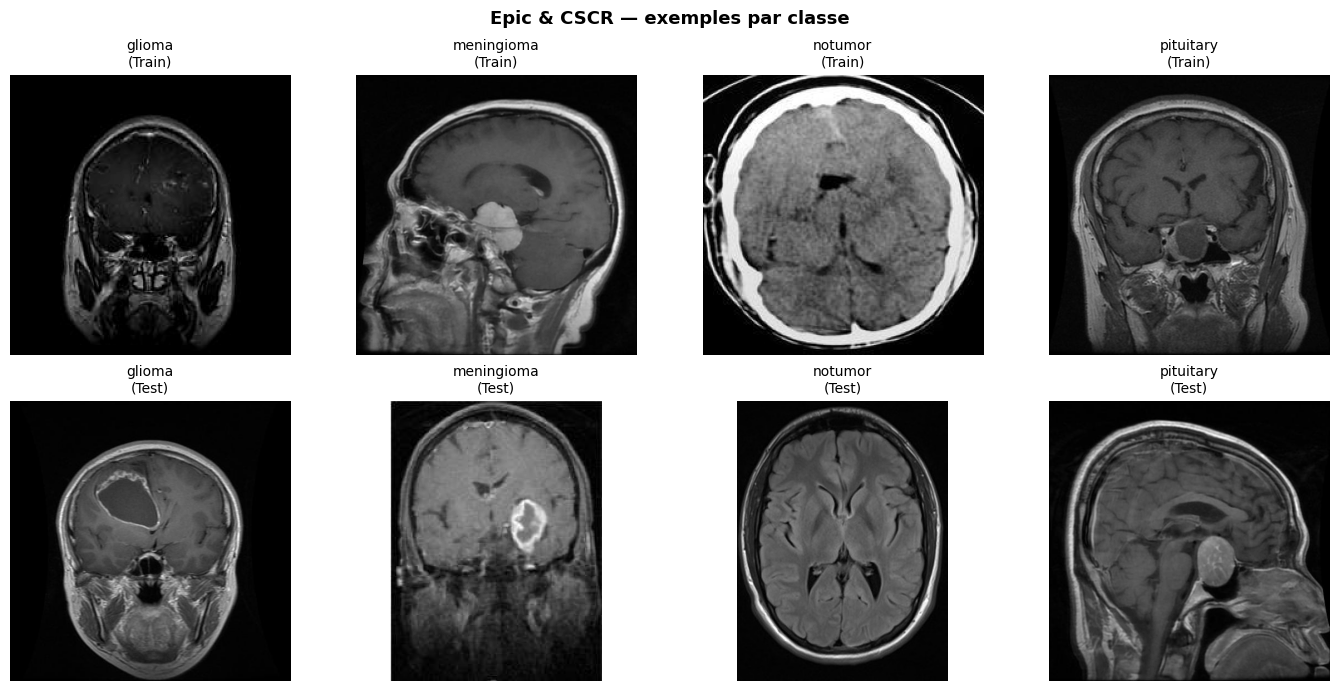

In [4]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for col, cls in enumerate(CLASSES):
    for row, split_dir in enumerate([TRAIN_DIR, TEST_DIR]):
        paths = glob.glob(os.path.join(split_dir, cls, "*.jpg"))
        if not paths:
            paths = glob.glob(os.path.join(split_dir, cls, "*.png"))
        path = random.choice(paths)
        img = Image.open(path).convert("L")
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"{cls}\n({'Train' if row==0 else 'Test'})", fontsize=10)
        axes[row, col].axis("off")
plt.suptitle("Epic & CSCR — exemples par classe", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_epic_examples.png", dpi=150)
plt.show()

### 1.2 Epic & CSCR - distribution des classes

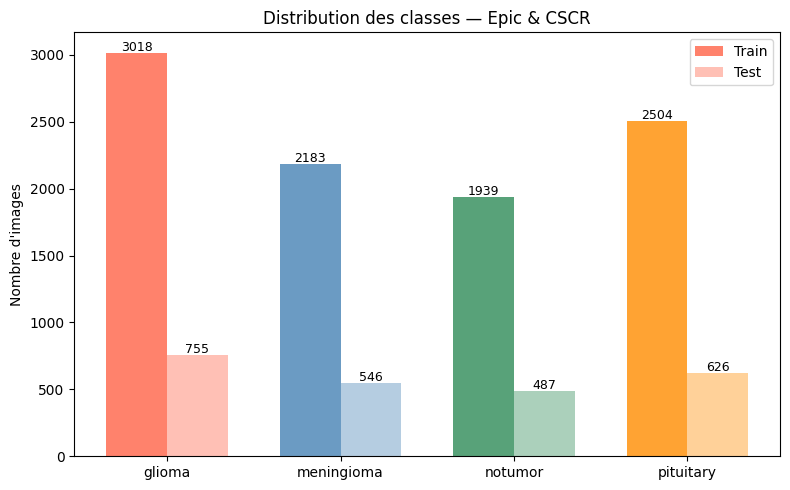

Total : 12058 images
  glioma       train=3018  test=755
  meningioma   train=2183  test=546
  notumor      train=1939  test=487
  pituitary    train=2504  test=626


In [6]:
counts_train = {cls: sum(len(glob.glob(os.path.join(TRAIN_DIR, cls, f"*.{ext}"))) for ext in ["jpg", "jpeg", "png"]) for cls in CLASSES}
counts_test  = {cls: sum(len(glob.glob(os.path.join(TEST_DIR,  cls, f"*.{ext}"))) for ext in ["jpg", "jpeg", "png"]) for cls in CLASSES}

x = np.arange(len(CLASSES))
width = 0.35
colors = ["tomato", "steelblue", "seagreen", "darkorange"]

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, counts_train.values(), width, label="Train", color=colors, alpha=0.8)
bars2 = ax.bar(x + width/2, counts_test.values(),  width, label="Test",  color=colors, alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha="center", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(int(bar.get_height())), ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes — Epic & CSCR")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_epic_distribution.png", dpi=150)
plt.show()

total = sum(counts_train.values()) + sum(counts_test.values())
print(f"Total : {total} images")
for cls in CLASSES:
    print(f"  {cls:12s} train={counts_train[cls]}  test={counts_test[cls]}")

### 1.3 IXI — distribution des âges

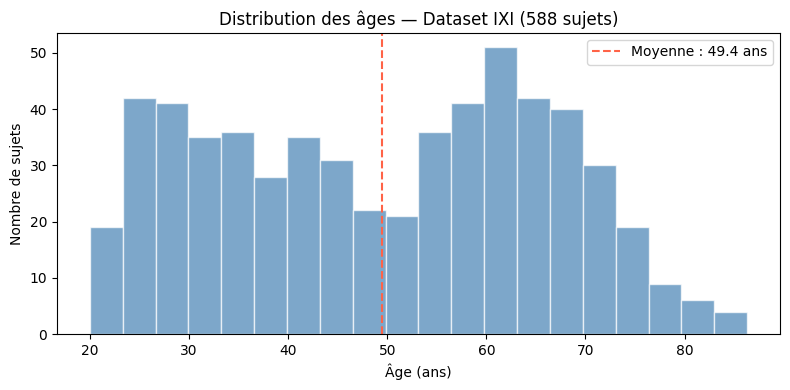

Sujets : 588
Âge min : 20.0  max : 86.3  mean : 49.4


In [13]:
import pandas as pd

ixi_csv = os.path.join(IXI_DIR, "IXI.xls")
df = pd.read_excel(ixi_csv)
df = df[df["AGE"].notna()]
ages = df["AGE"].values

import re
available_ids = set()
for p in glob.glob(os.path.join(IXI_DIR, "**", "*.nii.gz"), recursive=True):
    m = re.match(r'IXI(\d+)', os.path.basename(p))
    if m:
        available_ids.add(int(m.group(1)))

df = df[df["IXI_ID"].isin(available_ids)]
ages = df["AGE"].values
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ages, bins=20, color="steelblue", alpha=0.7, edgecolor="white")
ax.axvline(ages.mean(), color="tomato", linestyle="--", label=f"Moyenne : {ages.mean():.1f} ans")
ax.set_xlabel("Âge (ans)")
ax.set_ylabel("Nombre de sujets")
ax.set_title(f"Distribution des âges — Dataset IXI ({len(ages)} sujets)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_ixi_ages.png", dpi=150)
plt.show()

print(f"Sujets : {len(ages)}")
print(f"Âge min : {ages.min():.1f}  max : {ages.max():.1f}  mean : {ages.mean():.1f}")

### 1.4 IXI - exemples de coupes 2D extraites

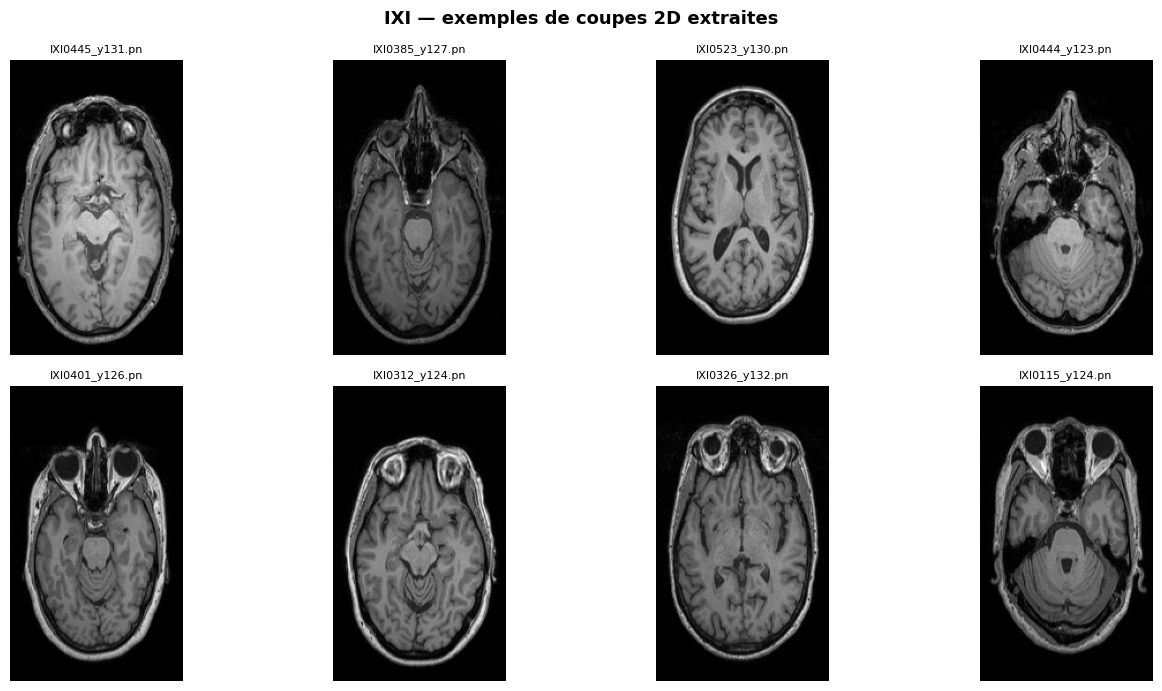

In [7]:
slices_dir = "runs_brain_age/slices_2d"
all_slices = glob.glob(os.path.join(slices_dir, "*.png"))
if not all_slices:
    all_slices = glob.glob(os.path.join(slices_dir, "*.jpg"))

sample_slices = random.sample(all_slices, min(8, len(all_slices)))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, path in zip(axes.flatten(), sample_slices):
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(os.path.basename(path)[:15], fontsize=8)
    ax.axis("off")
plt.suptitle("IXI — exemples de coupes 2D extraites", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_ixi_examples.png", dpi=150)
plt.show()

### 1.5 Br35H - exemples yes / no et masque de segmentation

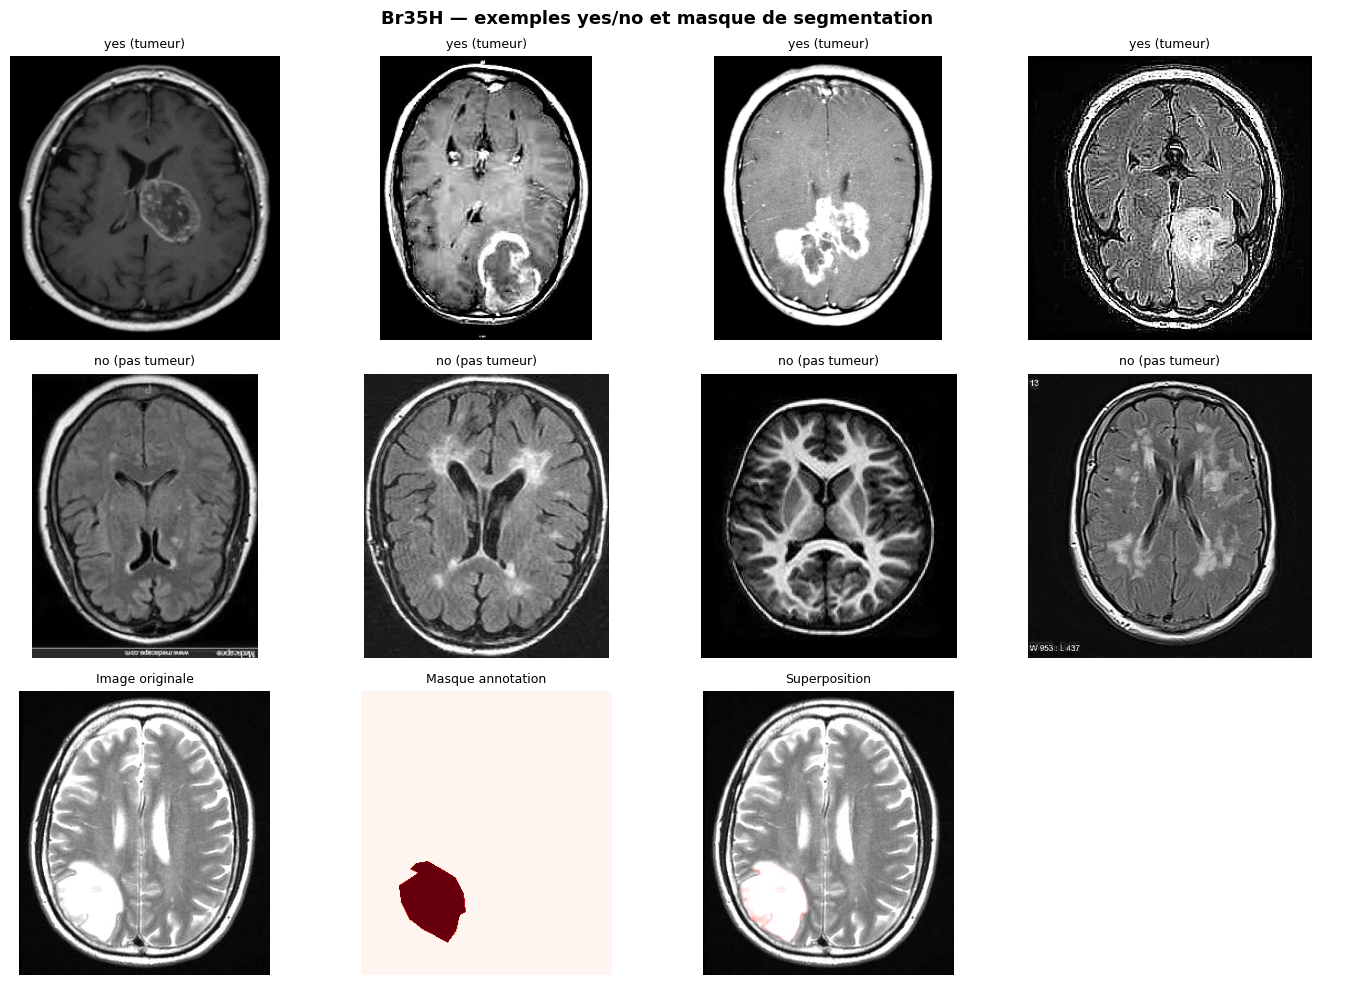

In [8]:
yes_paths = random.sample(glob.glob(os.path.join(BR35H_YES, "*.jpg")), 4)
no_paths  = random.sample(glob.glob(os.path.join(BR35H_NO,  "*.jpg")), 4)

with open(os.path.join(BR35H_MASK, "annotations_all.json")) as f:
    annot = json.load(f)

if "_via_img_metadata" in annot:
    annot = annot["_via_img_metadata"]

annotated = [(k, v) for k, v in annot.items()
             if v.get("regions") and len(v["regions"]) > 0]
key, entry = random.choice(annotated)
img_path_mask = os.path.join(BR35H_MASK, "TRAIN", entry["filename"])
if not os.path.exists(img_path_mask):
    img_path_mask = os.path.join(BR35H_YES, entry["filename"])

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col, p in enumerate(yes_paths):
    axes[0, col].imshow(Image.open(p).convert("L"), cmap="gray")
    axes[0, col].set_title("yes (tumeur)", fontsize=9)
    axes[0, col].axis("off")

for col, p in enumerate(no_paths):
    axes[1, col].imshow(Image.open(p).convert("L"), cmap="gray")
    axes[1, col].set_title("no (pas tumeur)", fontsize=9)
    axes[1, col].axis("off")

if os.path.exists(img_path_mask):
    img_orig = np.array(Image.open(img_path_mask).convert("L"))
    H, W = img_orig.shape
    mask = np.zeros((H, W), dtype=np.uint8)
    import cv2
    for region in entry["regions"]:
        shape = region.get("shape_attributes", region)
        xs = shape.get("all_points_x", [])
        ys = shape.get("all_points_y", [])
        if len(xs) >= 3:
            pts = np.array(list(zip(xs, ys)), dtype=np.int32)
            cv2.fillPoly(mask, [pts], 1)
    axes[2, 0].imshow(img_orig, cmap="gray")
    axes[2, 0].set_title("Image originale", fontsize=9)
    axes[2, 0].axis("off")
    axes[2, 1].imshow(mask, cmap="Reds")
    axes[2, 1].set_title("Masque annotation", fontsize=9)
    axes[2, 1].axis("off")
    overlay = np.stack([img_orig]*3, axis=-1).astype(float)
    overlay[mask == 1, 0] = 255
    axes[2, 2].imshow(overlay.astype(np.uint8))
    axes[2, 2].set_title("Superposition", fontsize=9)
    axes[2, 2].axis("off")
axes[2, 3].axis("off")

plt.suptitle("Br35H — exemples yes/no et masque de segmentation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_br35h_examples.png", dpi=150)
plt.show()

### 1.6 Br35H - distribution des classes

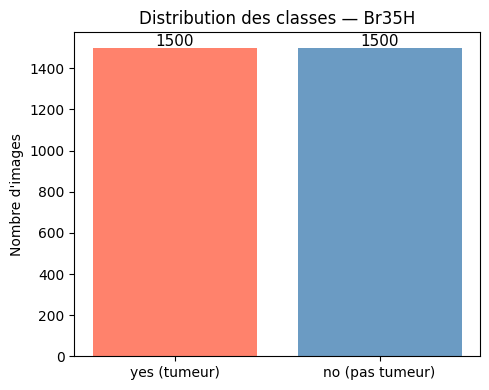

Total : 3000 images  (yes=1500, no=1500)


In [9]:
n_yes = len(glob.glob(os.path.join(BR35H_YES, "*.jpg")))
n_no  = len(glob.glob(os.path.join(BR35H_NO,  "*.jpg")))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["yes (tumeur)", "no (pas tumeur)"], [n_yes, n_no],
       color=["tomato", "steelblue"], alpha=0.8)
for i, v in enumerate([n_yes, n_no]):
    ax.text(i, v + 10, str(v), ha="center", fontsize=11)
ax.set_ylabel("Nombre d'images")
ax.set_title("Distribution des classes — Br35H")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/dataset_br35h_distribution.png", dpi=150)
plt.show()
print(f"Total : {n_yes + n_no} images  (yes={n_yes}, no={n_no})")

## 2. Bootstrap sur les ratios σ par classe

In [6]:
with open("predicted_clinical.pkl", "rb") as f:
    predicted_clinical = pickle.load(f)

class BNNMultimodalNet(nn.Module):
    def __init__(self, num_classes=4, clinical_dim=1, prior_mu=0, prior_sigma=0.1):
        super().__init__()
        backbone = models.resnet18(weights="IMAGENET1K_V1")
        backbone.fc = nn.Identity()
        self.cnn = backbone
        for param in self.cnn.parameters():
            param.requires_grad = False
        self.clinical_mlp = nn.Sequential(
            nn.Linear(clinical_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        self.bnn_head = nn.Sequential(
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=512+32, out_features=256),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=256, out_features=128),
            nn.ReLU(),
            bnn.BayesLinear(prior_mu=prior_mu, prior_sigma=prior_sigma,
                            in_features=128, out_features=num_classes),
        )
    def forward(self, img, clinical):
        return self.bnn_head(torch.cat([self.cnn(img), self.clinical_mlp(clinical)], dim=1))

model_bnn = BNNMultimodalNet().to(device)
ckpt = torch.load(BNN_CKPT, map_location=device, weights_only=False)
model_bnn.load_state_dict(ckpt["model_state"])
model_bnn.eval()
print("BNN chargé")

BNN chargé


In [16]:
all_paths, all_labels_list = [], []
for idx, cls in enumerate(CLASSES):
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    all_paths.extend(paths)
    all_labels_list.extend([idx] * len(paths))

all_labels_arr = np.array(all_labels_list)
all_sigmas_arr, all_preds_arr = [], []

model_bnn.eval()
with torch.no_grad():
    for p in all_paths:
        img_t  = load_image(p)
        clin_v = predicted_clinical.get(p, predicted_clinical.get(os.path.basename(p), 0.5))
        clin_t = torch.tensor([[float(clin_v)]], dtype=torch.float32).to(device)
        passes = torch.stack([
            torch.softmax(model_bnn(img_t, clin_t), dim=1)
            for _ in range(MC_PASSES)
        ])
        mean_p = passes.mean(0).cpu().numpy()[0]
        std_p  = passes.std(0).cpu().numpy()[0]
        all_preds_arr.append(mean_p.argmax())
        all_sigmas_arr.append(std_p[mean_p.argmax()])

all_preds_arr  = np.array(all_preds_arr)
all_sigmas_arr = np.array(all_sigmas_arr)
print(f"Inférence terminée sur {len(all_paths)} images")

Inférence terminée sur 2413 images


In [17]:
N_BOOTSTRAP = 1000
SAMPLE_FRAC = 0.25
n_total = len(all_paths)
n_sample = int(n_total * SAMPLE_FRAC)

bootstrap_ratios = {cls: [] for cls in CLASSES}

# tirage avec remise sur l'ensemble test pour estimer la variabilité du ratio
for _ in range(N_BOOTSTRAP):
    idx = np.random.choice(n_total, n_sample, replace=True)
    labels_b = all_labels_arr[idx]
    preds_b  = all_preds_arr[idx]
    sigmas_b = all_sigmas_arr[idx]

    for i, cls in enumerate(CLASSES):
        mask_cls   = (labels_b == i)
        correct    = mask_cls & (preds_b == labels_b)
        incorrect  = mask_cls & (preds_b != labels_b)
        if incorrect.sum() > 0 and correct.sum() > 0:
            ratio = sigmas_b[incorrect].mean() / sigmas_b[correct].mean()
            bootstrap_ratios[cls].append(ratio)

print("Bootstrap terminé")
for cls in CLASSES:
    r = np.array(bootstrap_ratios[cls])
    if len(r) > 0:
        print(f"  {cls:12s}  médiane={np.median(r):.2f}  IC95=[{np.percentile(r,2.5):.2f}, {np.percentile(r,97.5):.2f}]  n={len(r)}")

Bootstrap terminé
  glioma        médiane=5.15  IC95=[3.13, 8.32]  n=1000
  meningioma    médiane=5.84  IC95=[1.16, 9.25]  n=918
  notumor       médiane=30.57  IC95=[17.27, 54.11]  n=234
  pituitary     médiane=22.75  IC95=[0.17, 36.66]  n=731


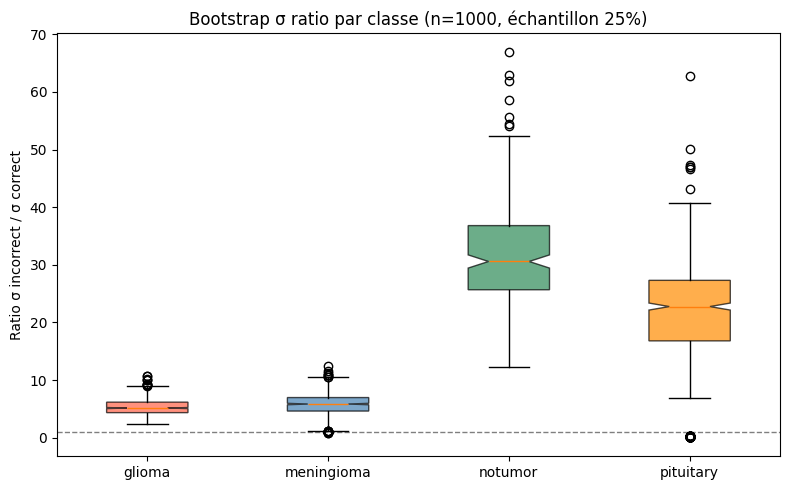

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))
data_plot = [bootstrap_ratios[cls] for cls in CLASSES]
colors = ["tomato", "steelblue", "seagreen", "darkorange"]

bp = ax.boxplot(data_plot, patch_artist=True, notch=True)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticklabels(CLASSES)
ax.set_ylabel("Ratio σ incorrect / σ correct")
ax.set_title(f"Bootstrap σ ratio par classe (n={N_BOOTSTRAP}, échantillon {int(SAMPLE_FRAC*100)}%)")
ax.axhline(1, color="black", linestyle="--", lw=1, alpha=0.5)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/bootstrap_sigma_ratio.png", dpi=150)
plt.show()

## 3. Comparaison ResNet18 / ResNet34 / ResNet50

In [19]:
from torch.utils.data import WeightedRandomSampler
import re

val_tf_resnet = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

train_full = datasets.ImageFolder(TRAIN_DIR, transform=val_tf_resnet)

def get_patient_id(filepath):
    fname = os.path.basename(filepath)
    for pattern in [r'^(Tr|Te)-\w+_\d+', r'^[A-Z]_\d+', r'^(\w+_\d+)_\d+$', r'^(.+)_\d+\.\w+$']:
        m = re.match(pattern, fname)
        if m:
            return m.group(0)
    return fname.rsplit("_", 1)[0]

subject_ids = list(set([get_patient_id(s[0]) for s in train_full.samples]))
random.shuffle(subject_ids)
val_ids = set(subject_ids[:int(0.15 * len(subject_ids))])

train_idx = [i for i, s in enumerate(train_full.samples) if get_patient_id(s[0]) not in val_ids]
val_idx   = [i for i, s in enumerate(train_full.samples) if get_patient_id(s[0]) in val_ids]

train_ds = Subset(train_full, train_idx)
val_ds   = Subset(datasets.ImageFolder(TRAIN_DIR, transform=val_tf_resnet), val_idx)
test_ds  = datasets.ImageFolder(TEST_DIR, transform=val_tf_resnet)

counts = np.bincount([train_full.samples[i][1] for i in train_idx])
weights = 1.0 / counts
sample_weights = torch.tensor([weights[train_full.samples[i][1]] for i in train_idx], dtype=torch.double)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader_r = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=0)
val_loader_r   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader_r  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 8144  Val: 1506  Test: 2414


In [20]:
def train_resnet(arch_name, epochs=10, lr=1e-4):
    if arch_name == "resnet18":
        m = models.resnet18(weights="IMAGENET1K_V1")
        in_f = 512
    elif arch_name == "resnet34":
        m = models.resnet34(weights="IMAGENET1K_V1")
        in_f = 512
    elif arch_name == "resnet50":
        m = models.resnet50(weights="IMAGENET1K_V1")
        in_f = 2048

    m.fc = nn.Sequential(nn.Linear(in_f, 256), nn.ReLU(), nn.Dropout(0.4), nn.Linear(256, 4))
    m = m.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(m.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_auc, best_state = -1, None
    for epoch in range(1, epochs + 1):
        m.train()
        for x, y in train_loader_r:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            nn.CrossEntropyLoss()(m(x), y).backward()
            optimizer.step()
        scheduler.step()

        m.eval()
        all_y, all_probs = [], []
        with torch.no_grad():
            for x, y in val_loader_r:
                probs = torch.softmax(m(x.to(device)), dim=1).cpu().numpy()
                all_y.extend(y.numpy()); all_probs.extend(probs)
        auc = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        print(f"  {arch_name} epoch {epoch:02d} val_auc={auc:.4f}")

    m.load_state_dict(best_state)
    m.eval()
    all_y, all_probs, all_preds = [], [], []
    with torch.no_grad():
        for x, y in test_loader_r:
            probs = torch.softmax(m(x.to(device)), dim=1).cpu().numpy()
            all_y.extend(y.numpy()); all_probs.extend(probs)
            all_preds.extend(probs.argmax(axis=1))
    auc  = roc_auc_score(all_y, all_probs, multi_class="ovr", average="macro")
    bacc = balanced_accuracy_score(all_y, all_preds)
    return {"arch": arch_name, "auc": auc, "bal_acc": bacc}

In [22]:
resnet_results = []
for arch in ["resnet18", "resnet34", "resnet50"]:
    print(f"\n=== {arch} ===")
    res = train_resnet(arch, epochs=10)
    resnet_results.append(res)
    print(f"  TEST  AUC={res['auc']:.4f}  BalAcc={res['bal_acc']:.4f}")

print("\n" + "="*45)
print(f"{'Architecture':<15} {'AUC':>8} {'BalAcc':>10}")
print("-"*45)
for r in resnet_results:
    print(f"{r['arch']:<15} {r['auc']:>8.4f} {r['bal_acc']:>10.4f}")


=== resnet18 ===
  resnet18 epoch 01 val_auc=0.9967
  resnet18 epoch 02 val_auc=0.9973
  resnet18 epoch 03 val_auc=0.9987
  resnet18 epoch 04 val_auc=0.9985
  resnet18 epoch 05 val_auc=0.9983
  resnet18 epoch 06 val_auc=0.9985
  resnet18 epoch 07 val_auc=0.9989
  resnet18 epoch 08 val_auc=0.9983
  resnet18 epoch 09 val_auc=0.9978
  resnet18 epoch 10 val_auc=0.9986
  TEST  AUC=0.9975  BalAcc=0.9720

=== resnet34 ===
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/teodul/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:14<00:00, 5.84MB/s]


  resnet34 epoch 01 val_auc=0.9965
  resnet34 epoch 02 val_auc=0.9970
  resnet34 epoch 03 val_auc=0.9974
  resnet34 epoch 04 val_auc=0.9989
  resnet34 epoch 05 val_auc=0.9982
  resnet34 epoch 06 val_auc=0.9985
  resnet34 epoch 07 val_auc=0.9981
  resnet34 epoch 08 val_auc=0.9981
  resnet34 epoch 09 val_auc=0.9980
  resnet34 epoch 10 val_auc=0.9981
  TEST  AUC=0.9957  BalAcc=0.9609

=== resnet50 ===
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/teodul/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:16<00:00, 6.06MB/s]


  resnet50 epoch 01 val_auc=0.9943
  resnet50 epoch 02 val_auc=0.9970
  resnet50 epoch 03 val_auc=0.9971
  resnet50 epoch 04 val_auc=0.9978
  resnet50 epoch 05 val_auc=0.9974
  resnet50 epoch 06 val_auc=0.9981
  resnet50 epoch 07 val_auc=0.9985
  resnet50 epoch 08 val_auc=0.9982
  resnet50 epoch 09 val_auc=0.9984
  resnet50 epoch 10 val_auc=0.9983
  TEST  AUC=0.9940  BalAcc=0.9595

Architecture         AUC     BalAcc
---------------------------------------------
resnet18          0.9975     0.9720
resnet34          0.9957     0.9609
resnet50          0.9940     0.9595


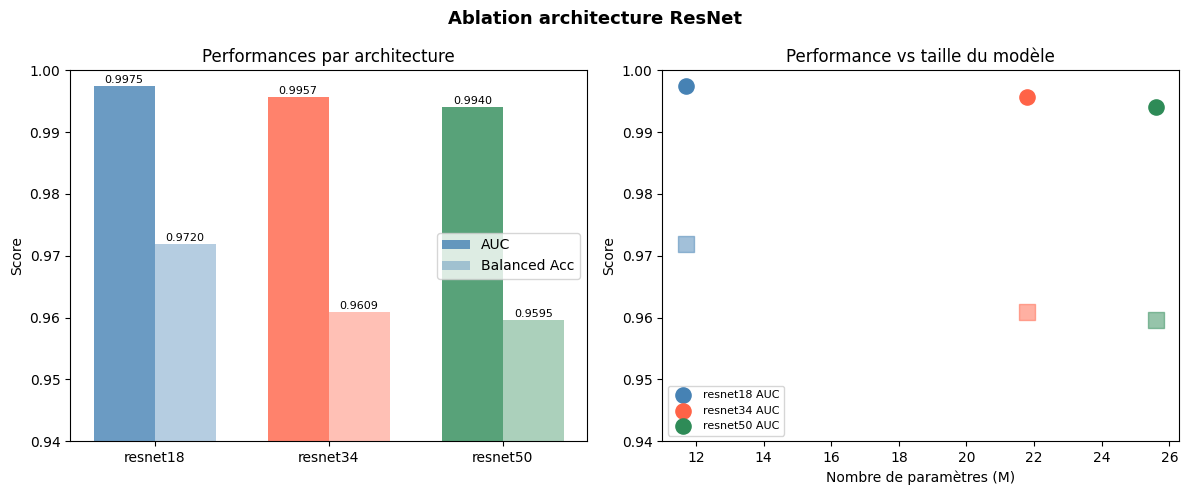

In [27]:
archs   = [r["arch"] for r in resnet_results]
aucs    = [r["auc"] for r in resnet_results]
baccs   = [r["bal_acc"] for r in resnet_results]
params  = {"resnet18": 11.7, "resnet34": 21.8, "resnet50": 25.6}

x = np.arange(len(archs))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars1 = axes[0].bar(x - width/2, aucs,  width, color=["steelblue", "tomato", "seagreen"], alpha=0.8, label="AUC")
bars2 = axes[0].bar(x + width/2, baccs, width, color=["steelblue", "tomato", "seagreen"], alpha=0.4, label="Balanced Acc")
axes[0].set_xticks(x)
axes[0].set_xticklabels(archs)
axes[0].set_ylim(0.94, 1.0)
axes[0].set_ylabel("Score")
axes[0].set_title("Performances par architecture")
axes[0].legend()
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=8)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f"{bar.get_height():.4f}", ha="center", fontsize=8)

n_params = [params[a] for a in archs]
colors   = ["steelblue", "tomato", "seagreen"]
for i, (arch, auc, bacc, n) in enumerate(zip(archs, aucs, baccs, n_params)):
    axes[1].scatter(n, auc,  color=colors[i], s=120, marker="o", label=f"{arch} AUC")
    axes[1].scatter(n, bacc, color=colors[i], s=120, marker="s", alpha=0.5)
axes[1].set_xlabel("Nombre de paramètres (M)")
axes[1].set_ylabel("Score")
axes[1].set_title("Performance vs taille du modèle")
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.94, 1.0)

plt.suptitle("Ablation architecture ResNet", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ablation_resnet.png", dpi=150)
plt.show()

## 4. Comparaison learning rate


=== LR = 1e-05 ===
  resnet18 epoch 01 val_auc=0.9737
  resnet18 epoch 02 val_auc=0.9908
  resnet18 epoch 03 val_auc=0.9956
  resnet18 epoch 04 val_auc=0.9966
  resnet18 epoch 05 val_auc=0.9969
  resnet18 epoch 06 val_auc=0.9975
  resnet18 epoch 07 val_auc=0.9975
  resnet18 epoch 08 val_auc=0.9977
  resnet18 epoch 09 val_auc=0.9977
  resnet18 epoch 10 val_auc=0.9977
  TEST  AUC=0.9950  BalAcc=0.9534

=== LR = 5e-05 ===
  resnet18 epoch 01 val_auc=0.9959
  resnet18 epoch 02 val_auc=0.9976
  resnet18 epoch 03 val_auc=0.9987
  resnet18 epoch 04 val_auc=0.9980
  resnet18 epoch 05 val_auc=0.9983
  resnet18 epoch 06 val_auc=0.9984
  resnet18 epoch 07 val_auc=0.9986
  resnet18 epoch 08 val_auc=0.9977
  resnet18 epoch 09 val_auc=0.9985
  resnet18 epoch 10 val_auc=0.9983
  TEST  AUC=0.9948  BalAcc=0.9488

=== LR = 0.0001 ===
  resnet18 epoch 01 val_auc=0.9944
  resnet18 epoch 02 val_auc=0.9972
  resnet18 epoch 03 val_auc=0.9970
  resnet18 epoch 04 val_auc=0.9981
  resnet18 epoch 05 val_auc=0.9

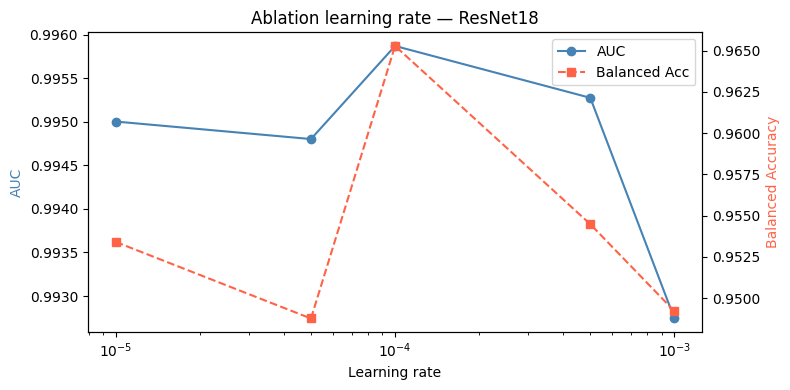

In [23]:
lr_results = []
for lr in [1e-5, 5e-5, 1e-4, 5e-4, 1e-3]:
    print(f"\n=== LR = {lr} ===")
    res = train_resnet("resnet18", epochs=10, lr=lr)
    res["lr"] = lr
    lr_results.append(res)
    print(f"  TEST  AUC={res['auc']:.4f}  BalAcc={res['bal_acc']:.4f}")

lrs   = [r["lr"] for r in lr_results]
aucs  = [r["auc"] for r in lr_results]
baccs = [r["bal_acc"] for r in lr_results]

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.semilogx(lrs, aucs,  "o-", color="steelblue", label="AUC")
ax2.semilogx(lrs, baccs, "s--", color="tomato",   label="Balanced Acc")
ax1.set_xlabel("Learning rate")
ax1.set_ylabel("AUC", color="steelblue")
ax2.set_ylabel("Balanced Accuracy", color="tomato")
ax1.set_title("Ablation learning rate — ResNet18")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/ablation_lr.png", dpi=150)
plt.show()

## 5. Incertitude hors cerveau → classe notumor ?

/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_71134/798730703.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_71134/798730703.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
/var/folders/3g/35kvkrgs5_s06lhp6ttrtp1m0000gn/T/ipykernel_71134/798730703.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
/

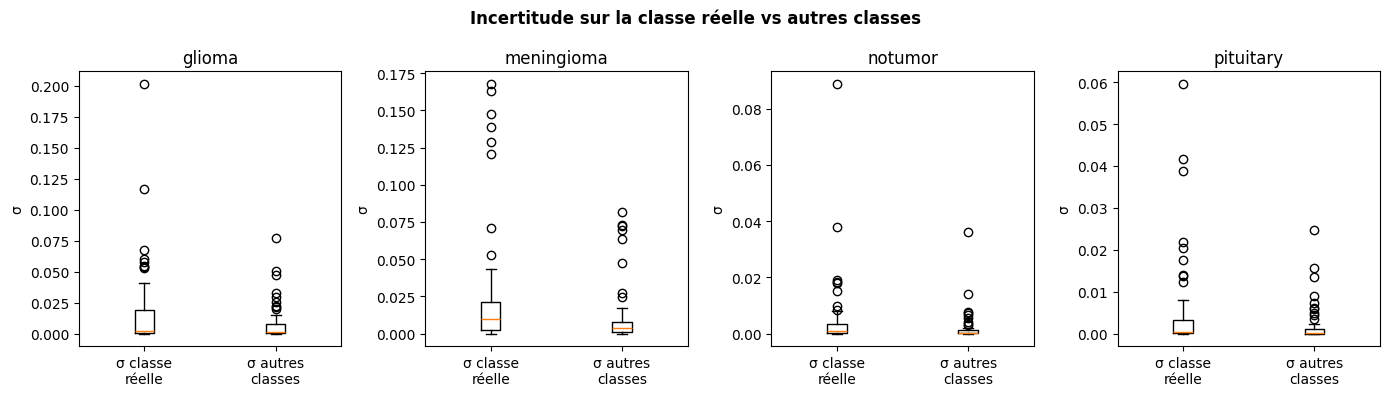

In [25]:
N_PER_CLASS = 50
CLIN_MED = np.array([[0.5]], dtype=np.float32)

results_outside = {cls: {"sigma_inside": [], "sigma_outside": []} for cls in CLASSES}

model_bnn.eval()
for cls in CLASSES:
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    sampled = random.sample(paths, min(N_PER_CLASS, len(paths)))
    true_idx = CLASSES.index(cls)

    for p in sampled:
        img_t  = load_image(p)
        clin_t = torch.tensor([[0.5]], dtype=torch.float32).to(device)
        with torch.no_grad():
            passes = torch.stack([
                torch.softmax(model_bnn(img_t, clin_t), dim=1)
                for _ in range(MC_PASSES)
            ])
        std_p = passes.std(0).cpu().numpy()[0]
        results_outside[cls]["sigma_inside"].append(std_p[true_idx])
        # moyenne de sigma sur toutes les classes sauf la vraie
        results_outside[cls]["sigma_outside"].append(std_p[[i for i in range(4) if i != true_idx]].mean())

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cls in zip(axes, CLASSES):
    inside  = results_outside[cls]["sigma_inside"]
    outside = results_outside[cls]["sigma_outside"]
    ax.boxplot([inside, outside], labels=["σ classe\nréelle", "σ autres\nclasses"])
    ax.set_title(cls)
    ax.set_ylabel("σ")
plt.suptitle("Incertitude sur la classe réelle vs autres classes", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/sigma_inside_vs_outside.png", dpi=150)
plt.show()

glioma terminé
meningioma terminé
notumor terminé
pituitary terminé


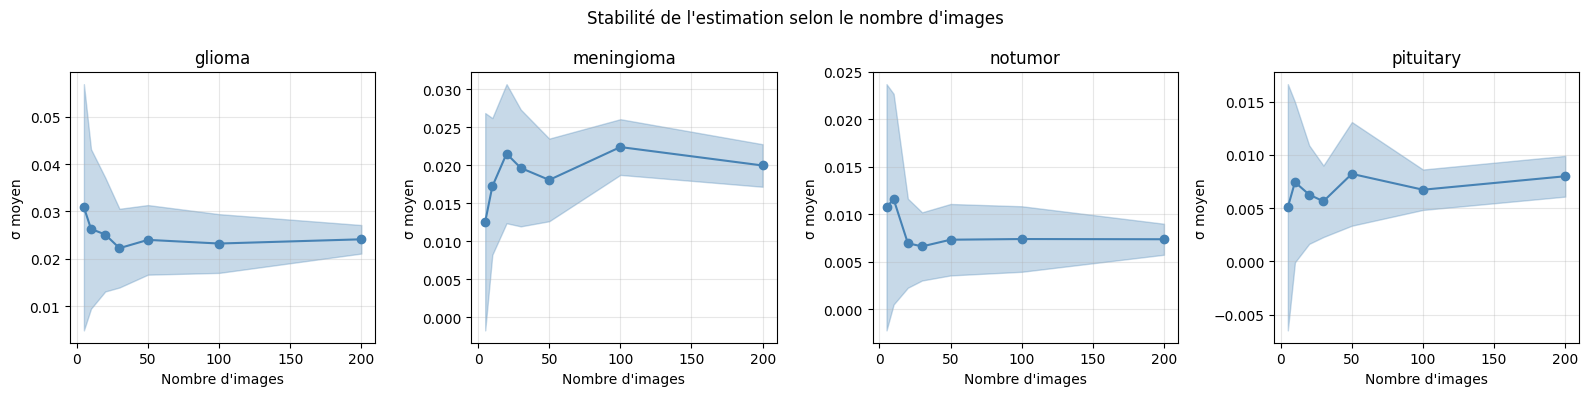


glioma:
  n=  5 → σ moyen = 0.0309 ± 0.0260
  n= 10 → σ moyen = 0.0263 ± 0.0168
  n= 20 → σ moyen = 0.0251 ± 0.0120
  n= 30 → σ moyen = 0.0222 ± 0.0083
  n= 50 → σ moyen = 0.0240 ± 0.0073
  n=100 → σ moyen = 0.0232 ± 0.0062
  n=200 → σ moyen = 0.0241 ± 0.0030

meningioma:
  n=  5 → σ moyen = 0.0126 ± 0.0143
  n= 10 → σ moyen = 0.0172 ± 0.0090
  n= 20 → σ moyen = 0.0215 ± 0.0092
  n= 30 → σ moyen = 0.0196 ± 0.0077
  n= 50 → σ moyen = 0.0181 ± 0.0054
  n=100 → σ moyen = 0.0224 ± 0.0037
  n=200 → σ moyen = 0.0200 ± 0.0028

notumor:
  n=  5 → σ moyen = 0.0108 ± 0.0130
  n= 10 → σ moyen = 0.0116 ± 0.0111
  n= 20 → σ moyen = 0.0070 ± 0.0047
  n= 30 → σ moyen = 0.0066 ± 0.0036
  n= 50 → σ moyen = 0.0073 ± 0.0038
  n=100 → σ moyen = 0.0074 ± 0.0035
  n=200 → σ moyen = 0.0074 ± 0.0016

pituitary:
  n=  5 → σ moyen = 0.0051 ± 0.0116
  n= 10 → σ moyen = 0.0074 ± 0.0075
  n= 20 → σ moyen = 0.0063 ± 0.0046
  n= 30 → σ moyen = 0.0056 ± 0.0034
  n= 50 → σ moyen = 0.0082 ± 0.0049
  n=100 → σ moyen = 

In [18]:
N_SIZES = [5, 10, 20, 30, 50, 100, 200]
N_PASSES_STABILITY = 10
N_BOOTSTRAP = 20

all_paths_by_class = {}
for cls in CLASSES:
    paths = glob.glob(os.path.join(TEST_DIR, cls, "*.jpg"))
    all_paths_by_class[cls] = paths

results = {cls: {n: [] for n in N_SIZES} for cls in CLASSES}

model_bnn.eval()
for cls in CLASSES:
    paths = all_paths_by_class[cls]
    for n in N_SIZES:
        for _ in range(N_BOOTSTRAP):
            sampled = random.sample(paths, min(n, len(paths)))
            sigmas = []
            for p in sampled:
                img_t = load_image(p)
                clin_t = torch.tensor([[0.5]], dtype=torch.float32).to(device)
                with torch.no_grad():
                    passes = torch.stack([
                        torch.softmax(model_bnn(img_t, clin_t), dim=1)
                        for _ in range(N_PASSES_STABILITY)
                    ])
                std_p = passes.std(0).cpu().numpy()[0]
                sigmas.append(std_p[CLASSES.index(cls)])
            results[cls][n].append(np.mean(sigmas))
    print(f"{cls} terminé")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, cls in zip(axes, CLASSES):
    means = [np.mean(results[cls][n]) for n in N_SIZES]
    stds  = [np.std(results[cls][n]) for n in N_SIZES]
    ax.plot(N_SIZES, means, "o-", color="steelblue")
    ax.fill_between(N_SIZES,
                    np.array(means) - np.array(stds),
                    np.array(means) + np.array(stds),
                    alpha=0.3, color="steelblue")
    ax.set_xlabel("Nombre d'images")
    ax.set_ylabel("σ moyen")
    ax.set_title(cls)
    ax.grid(True, alpha=0.3)

plt.suptitle("Stabilité de l'estimation selon le nombre d'images", fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/stability_n_images.png", dpi=150)
plt.show()

for cls in CLASSES:
    print(f"\n{cls}:")
    for n in N_SIZES:
        m = np.mean(results[cls][n])
        s = np.std(results[cls][n])
        print(f"  n={n:3d} → σ moyen = {m:.4f} ± {s:.4f}")